# Exam Surveillance AI Proctoring Prototype - Debugged Colab Version

**Author:** Hyunjun Yi  
**Mentor:** Dr. Qingyang Xiao

This Colab notebook is a **prototype pipeline** for detecting exam-proctoring risk signals in short surveillance-camera recordings, annotating the videos, and producing event logs for a human reviewer.

It detects and annotates the following **review flags**:

| Review flag | Prototype signal used |
|---|---|
| More than one person | YOLO object detection count of `person` objects |
| Cellphone visible | YOLO object detection of `cell phone` |
| Laptop / PC / tablet / screen / keyboard / mouse visible | YOLO COCO classes such as `laptop`, `tv`, `keyboard`, `mouse`, and `cell phone` as proxy classes |
| More than one screen-like device | Count of screen/device boxes such as `laptop`, `tv`, and `cell phone` |
| Speaking-like motion | MediaPipe face-landmark mouth-opening heuristic, visual-only |
| Pre-written scratch-sheet content | Optional scratch-paper ROI ink-density baseline heuristic |
| Scratch-sheet content changes | Optional ink-density change heuristic |

**Important:** this notebook does **not** make a final cheating determination. It only generates reviewable evidence, annotated video, and structured logs. A teacher/officer/examiner must review the outcome.

> **Debug fix in this version:** recent MediaPipe releases may not expose the old `mp.solutions` namespace. The notebook now supports both the legacy Face Mesh API and the newer MediaPipe Tasks Face Landmarker API, and it safely disables only the speaking-like flag if neither backend is available.


## Safety, privacy, and accuracy notes

Use this as a human-in-the-loop review assistant, not as an automated disciplinary system.

* The output label is **suspicious event**, not **cheating**.
* Do not use face recognition, identity matching, protected-attribute inference, or hidden surveillance.
* Obtain consent and comply with school, exam, labor, privacy, and data-retention rules.
* Keep raw videos and annotated videos secure.


# 1. Install dependencies

In [1]:
#@title 1. Install dependencies
# YOLO is used for object detection.
# MediaPipe is used for face landmarks / mouth movement.
# This debugged notebook supports both legacy mp.solutions and the current mp.tasks API.

!python --version
!pip -q install -U ultralytics opencv-python-headless pandas numpy tqdm moviepy ipywidgets requests
!pip -q install -U mediapipe || echo "MediaPipe install failed; speaking-like visual flag will be disabled."
!apt-get -qq update && apt-get -qq install -y ffmpeg >/dev/null

print("Setup complete. Continue with the Imports and environment checks cell.")


Python 3.13.15
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
#@title 2. Imports and environment checks
from __future__ import annotations

import json
import math
import os
import shutil
import statistics
import subprocess
import textwrap
import time
import urllib.request
from dataclasses import dataclass, asdict
from pathlib import Path
from types import SimpleNamespace
from typing import Any, Dict, Iterable, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import HTML, Video, display

try:
    from google.colab import files  # type: ignore
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False

try:
    from ultralytics import YOLO
    HAS_YOLO = True
except Exception as exc:
    YOLO = None
    HAS_YOLO = False
    print("Ultralytics import failed:", repr(exc))

try:
    import mediapipe as mp
    HAS_MEDIAPIPE = True
except Exception as exc:
    mp = None
    HAS_MEDIAPIPE = False
    print("MediaPipe import failed. Speaking-like visual flag disabled:", repr(exc))

MEDIAPIPE_LEGACY_AVAILABLE = bool(
    HAS_MEDIAPIPE
    and mp is not None
    and hasattr(mp, "solutions")
    and hasattr(mp.solutions, "face_mesh")
)
MEDIAPIPE_TASKS_AVAILABLE = bool(
    HAS_MEDIAPIPE
    and mp is not None
    and hasattr(mp, "tasks")
    and hasattr(mp.tasks, "vision")
    and hasattr(mp.tasks.vision, "FaceLandmarker")
)

print("Running in Colab:", IN_COLAB)
print("YOLO available:", HAS_YOLO)
print("MediaPipe available:", HAS_MEDIAPIPE)
if HAS_MEDIAPIPE and mp is not None:
    print("MediaPipe version:", getattr(mp, "__version__", "unknown"))
    print("MediaPipe module path:", getattr(mp, "__file__", "unknown"))
print("Legacy mp.solutions Face Mesh available:", MEDIAPIPE_LEGACY_AVAILABLE)
print("MediaPipe Tasks Face Landmarker available:", MEDIAPIPE_TASKS_AVAILABLE)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Running in Colab: True
YOLO available: True
MediaPipe available: True
MediaPipe version: 1.0.1
MediaPipe module path: /usr/local/lib/python3.13/dist-packages/mediapipe/__init__.py
Legacy mp.solutions Face Mesh available: False
MediaPipe Tasks Face Landmarker available: True


In [3]:
#@title 3. Configuration
@dataclass
class ExamProctorConfig:
    # Newer Ultralytics docs may expose newer model names. The loader tries these in order.
    # If yolo26n.pt is unavailable in your environment, it falls back to yolo11n.pt and then yolov8n.pt.
    yolo_model_candidates: Tuple[str, ...] = ("yolo26n.pt", "yolo11n.pt", "yolov8n.pt")
    yolo_conf: float = 0.25
    yolo_iou: float = 0.50
    yolo_imgsz: int = 640
    yolo_device: Optional[str] = None  # None = auto, "cpu" = force CPU, "0" = first GPU

    # For speed, run detector every N frames and reuse the latest result between processed frames.
    sample_every_n_frames: int = 2
    max_frames: Optional[int] = None  # Set a small number for debugging, e.g. 300.

    # Output
    output_dir: str = "/content/proctor_outputs"
    convert_to_h264: bool = True
    draw_all_detections: bool = True

    # Box filtering
    min_box_area_ratio: float = 0.002

    # Event smoothing / minimum durations
    event_max_gap_sec: float = 0.70
    multiple_people_min_duration_sec: float = 1.00
    phone_min_duration_sec: float = 0.40
    device_min_duration_sec: float = 0.50
    screen_count_min_duration_sec: float = 1.00
    speaking_min_duration_sec: float = 0.80
    paper_min_duration_sec: float = 1.00

    # Speaking-like mouth movement heuristic. This is visual-only and approximate.
    mouth_baseline_seconds: float = 2.00
    speaking_mar_min: float = 0.080
    speaking_mar_margin: float = 0.030

    # Current MediaPipe Tasks releases require a Face Landmarker model bundle.
    # It is downloaded automatically once when mp.solutions.face_mesh is unavailable.
    face_landmarker_model_path: str = "/content/face_landmarker.task"
    face_landmarker_model_url: str = (
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/face_landmarker.task"
    )

    # Optional scratch-paper ROI. Use either pixel coordinates (x1,y1,x2,y2) or normalized 0..1 coordinates.
    # Example: paper_roi=(0.10, 0.55, 0.55, 0.95)
    paper_roi: Optional[Tuple[float, float, float, float]] = None
    auto_detect_paper_roi: bool = False
    paper_min_area_ratio: float = 0.020
    paper_baseline_seconds: float = 3.00
    prewritten_ink_density_threshold: float = 0.025
    ink_density_increase_threshold: float = 0.015

    # Risk score threshold only affects report sorting, not the event flags themselves.
    risk_score_threshold: float = 0.50

CFG = ExamProctorConfig()
print(CFG)


ExamProctorConfig(yolo_model_candidates=('yolo26n.pt', 'yolo11n.pt', 'yolov8n.pt'), yolo_conf=0.25, yolo_iou=0.5, yolo_imgsz=640, yolo_device=None, sample_every_n_frames=2, max_frames=None, output_dir='/content/proctor_outputs', convert_to_h264=True, draw_all_detections=True, min_box_area_ratio=0.002, event_max_gap_sec=0.7, multiple_people_min_duration_sec=1.0, phone_min_duration_sec=0.4, device_min_duration_sec=0.5, screen_count_min_duration_sec=1.0, speaking_min_duration_sec=0.8, paper_min_duration_sec=1.0, mouth_baseline_seconds=2.0, speaking_mar_min=0.08, speaking_mar_margin=0.03, face_landmarker_model_path='/content/face_landmarker.task', face_landmarker_model_url='https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task', paper_roi=None, auto_detect_paper_roi=False, paper_min_area_ratio=0.02, paper_baseline_seconds=3.0, prewritten_ink_density_threshold=0.025, ink_density_increase_threshold=0.015, risk_score_threshold=0.5)


# Upload videos

Run the next cell and upload one or more short `.mp4`, `.mov`, `.avi` or `.mkv` exam recordings. THe notebook will process every video in `VIDEO_PATHS`.

For Google Drive files, mount Drive and set `VIDEO_PATHS` manually, for example:

```python
from google.colab import drive
drive.mount('/content/drive')
VIDEO_PATHS = ['/content/drive/MyDrive/exam_video_01.mp4']
```

In [4]:
#@title 4. Upload exam videos

def upload_exam_videos() -> List[str]:
    if not IN_COLAB or files is None:
        raise RuntimeError("files.upload() is only available in Google Colab. Set VIDEO_PATHS manually.")
    uploaded = files.upload()
    paths = list(uploaded.keys())
    print("Uploaded videos:", paths)
    return paths

# Run this cell and choose video files.
VIDEO_PATHS = upload_exam_videos()


Saving Yousef1_clip_35s.mp4 to Yousef1_clip_35s.mp4
Uploaded videos: ['Yousef1_clip_35s.mp4']


## Optional: inspect a frame and choose scratch-paper ROI

The scratch-paper detector works best when you give it a fixed region of interest. Run the next helper after uploading a video, then set `CFG.paper_roi` in the configuration cell or in a new cell.

Normalized ROI format: `(x1, y1, x2, y2)` with each value from `0` to `1`.

Example:

```python
CFG.paper_roi = (0.08, 0.55, 0.58, 0.95)
```

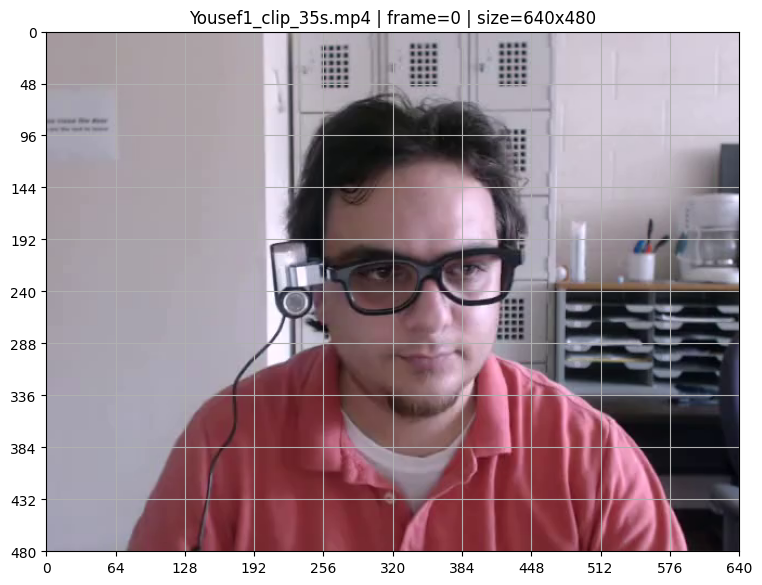

Normalized ROI example: x1/w, y1/h, x2/w, y2/h


In [5]:
#@title 5. Optional helper: show first frame with a coordinate grid

def read_frame_at(video_path: str, frame_index: int = 0) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_index} from {video_path}")
    return frame


def show_frame_with_grid(video_path: str, frame_index: int = 0, max_width: int = 900) -> None:
    import matplotlib.pyplot as plt

    frame = read_frame_at(video_path, frame_index)
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig_w = min(12, max(6, max_width / 100))
    fig_h = fig_w * h / w
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(rgb)
    plt.title(f"{video_path} | frame={frame_index} | size={w}x{h}")
    plt.xlim(0, w)
    plt.ylim(h, 0)
    plt.xticks(np.linspace(0, w, 11).astype(int))
    plt.yticks(np.linspace(0, h, 11).astype(int))
    plt.grid(True)
    plt.show()
    print("Normalized ROI example: x1/w, y1/h, x2/w, y2/h")

# Uncomment after uploading videos:
show_frame_with_grid(VIDEO_PATHS[0], frame_index=0)


In [6]:
#@title 6. Core utilities: YOLO loading, boxes, face landmarks, scratch-paper heuristic
SUSPICIOUS_OBJECT_LABELS = {
    "cell phone": "cell_phone_visible",
    "laptop": "disallowed_computer_or_screen_visible",
    "tv": "disallowed_computer_or_screen_visible",
    "keyboard": "disallowed_computer_or_screen_visible",
    "mouse": "disallowed_computer_or_screen_visible",
    "remote": "disallowed_computer_or_screen_visible",
}

SCREEN_LIKE_LABELS = {"laptop", "tv", "cell phone"}
DEVICE_PROXY_LABELS = {"cell phone", "laptop", "tv", "keyboard", "mouse", "remote"}

PRETTY_FLAG_NAMES = {
    "multiple_people": "multiple people",
    "cell_phone_visible": "cell phone visible",
    "disallowed_computer_or_screen_visible": "device/screen visible",
    "more_than_one_screen_device_visible": "more than one screen/device",
    "speaking_like_mouth_motion": "speaking-like mouth motion",
    "prewritten_scratch_sheet_possible": "possible pre-written scratch sheet",
    "scratch_sheet_content_changed": "scratch sheet content changed",
    "online_search_proxy_visible": "online-search proxy: screen/keyboard/mouse visible",
}

FLAG_WEIGHTS = {
    "multiple_people": 0.25,
    "cell_phone_visible": 0.30,
    "disallowed_computer_or_screen_visible": 0.20,
    "more_than_one_screen_device_visible": 0.20,
    "speaking_like_mouth_motion": 0.12,
    "prewritten_scratch_sheet_possible": 0.18,
    "scratch_sheet_content_changed": 0.16,
    "online_search_proxy_visible": 0.12,
}


def label_from_model_names(names: Any, cls_id: int) -> str:
    if isinstance(names, dict):
        return str(names.get(cls_id, cls_id))
    if isinstance(names, list) and 0 <= cls_id < len(names):
        return str(names[cls_id])
    return str(cls_id)


def box_area_ratio(xyxy: Iterable[float], frame_shape: Tuple[int, int, int]) -> float:
    x1, y1, x2, y2 = [float(v) for v in xyxy]
    h, w = frame_shape[:2]
    return max(0.0, (x2 - x1)) * max(0.0, (y2 - y1)) / max(1.0, float(w * h))


def load_yolo_model(cfg: ExamProctorConfig):
    if not HAS_YOLO or YOLO is None:
        raise RuntimeError("Ultralytics YOLO is not available. Re-run the install cell.")
    errors = []
    for model_name in cfg.yolo_model_candidates:
        try:
            print(f"Trying YOLO model: {model_name}")
            model = YOLO(model_name)
            print(f"Loaded YOLO model: {model_name}")
            return model, model_name
        except Exception as exc:
            errors.append(f"{model_name}: {repr(exc)}")
    raise RuntimeError("Could not load any YOLO model:\n" + "\n".join(errors))


def parse_yolo_boxes(result: Any, frame_shape: Tuple[int, int, int], cfg: ExamProctorConfig) -> List[Dict[str, Any]]:
    boxes: List[Dict[str, Any]] = []
    names = getattr(result, "names", None)
    if names is None and hasattr(result, "model"):
        names = getattr(result.model, "names", None)

    if not hasattr(result, "boxes") or result.boxes is None:
        return boxes

    for box in result.boxes:
        xyxy = box.xyxy[0].detach().cpu().numpy().astype(float).tolist()
        conf = float(box.conf[0].detach().cpu().item()) if box.conf is not None else 0.0
        cls_id = int(box.cls[0].detach().cpu().item()) if box.cls is not None else -1
        label = label_from_model_names(names, cls_id)
        area_ratio = box_area_ratio(xyxy, frame_shape)
        if area_ratio < cfg.min_box_area_ratio:
            continue
        boxes.append({
            "label": label,
            "cls_id": cls_id,
            "conf": conf,
            "xyxy": xyxy,
            "area_ratio": area_ratio,
        })
    return boxes


class LegacyFaceMeshAdapter:
    """Give the legacy FaceMesh object the same small interface as the Tasks adapter."""

    def __init__(self) -> None:
        self.detector = mp.solutions.face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
        )

    def process(self, rgb_frame: np.ndarray):
        return self.detector.process(rgb_frame)

    def close(self) -> None:
        self.detector.close()


class TasksFaceMeshAdapter:
    """Compatibility wrapper for MediaPipe Tasks FaceLandmarker.

    It converts the Tasks result into the `multi_face_landmarks` structure used
    by the rest of this notebook, so the video-processing code stays unchanged.
    """

    def __init__(self, cfg: ExamProctorConfig) -> None:
        model_path = Path(cfg.face_landmarker_model_path)
        model_path.parent.mkdir(parents=True, exist_ok=True)

        # A partial or interrupted download is replaced automatically.
        if not model_path.exists() or model_path.stat().st_size < 100_000:
            print("Downloading MediaPipe Face Landmarker model...")
            urllib.request.urlretrieve(cfg.face_landmarker_model_url, str(model_path))
            print(f"Saved Face Landmarker model to: {model_path}")

        vision = mp.tasks.vision
        options = vision.FaceLandmarkerOptions(
            base_options=mp.tasks.BaseOptions(model_asset_path=str(model_path)),
            running_mode=vision.RunningMode.VIDEO,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.detector = vision.FaceLandmarker.create_from_options(options)
        self._timestamp_ms = -1

    def process(self, rgb_frame: np.ndarray):
        # MediaPipe VIDEO mode requires monotonically increasing timestamps.
        # The exact value is not used by the notebook's mouth-ratio calculation.
        self._timestamp_ms += 33
        rgb_frame = np.ascontiguousarray(rgb_frame)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        result = self.detector.detect_for_video(mp_image, self._timestamp_ms)

        # Convert List[List[NormalizedLandmark]] to the legacy object shape:
        # result.multi_face_landmarks[0].landmark[index].x / .y
        compatible_faces = [
            SimpleNamespace(landmark=face_landmarks)
            for face_landmarks in getattr(result, "face_landmarks", [])
        ]
        return SimpleNamespace(multi_face_landmarks=compatible_faces)

    def close(self) -> None:
        self.detector.close()


def make_face_mesh(cfg: ExamProctorConfig):
    """Create a face-landmark backend without assuming `mp.solutions` exists."""
    if not HAS_MEDIAPIPE or mp is None:
        print("MediaPipe unavailable; speaking-like mouth-motion flag disabled.")
        return None

    if MEDIAPIPE_LEGACY_AVAILABLE:
        print("Using MediaPipe legacy Face Mesh backend.")
        try:
            return LegacyFaceMeshAdapter()
        except Exception as exc:
            print("Legacy Face Mesh initialization failed:", repr(exc))

    if MEDIAPIPE_TASKS_AVAILABLE:
        print("Using MediaPipe Tasks Face Landmarker backend.")
        try:
            return TasksFaceMeshAdapter(cfg)
        except Exception as exc:
            print("MediaPipe Tasks Face Landmarker initialization failed:", repr(exc))

    print(
        "No compatible MediaPipe face-landmark API was found. "
        "Object detection will continue, but speaking-like flags are disabled."
    )
    return None


def mouth_aspect_ratio_from_facemesh(face_landmarks: Any, frame_shape: Tuple[int, int, int]) -> Optional[float]:
    # MediaPipe FaceMesh landmark IDs:
    # 13 = upper inner lip, 14 = lower inner lip, 78/308 = mouth corners.
    h, w = frame_shape[:2]
    lm = face_landmarks.landmark
    needed = [13, 14, 78, 308]
    if max(needed) >= len(lm):
        return None
    upper = np.array([lm[13].x * w, lm[13].y * h], dtype=float)
    lower = np.array([lm[14].x * w, lm[14].y * h], dtype=float)
    left = np.array([lm[78].x * w, lm[78].y * h], dtype=float)
    right = np.array([lm[308].x * w, lm[308].y * h], dtype=float)
    vertical = float(np.linalg.norm(upper - lower))
    horizontal = float(np.linalg.norm(left - right))
    if horizontal <= 1e-6:
        return None
    return vertical / horizontal


def resolve_roi(frame_shape: Tuple[int, int, int], roi: Optional[Tuple[float, float, float, float]]) -> Optional[Tuple[int, int, int, int]]:
    if roi is None:
        return None
    h, w = frame_shape[:2]
    x1, y1, x2, y2 = roi
    # Values in 0..1 are treated as normalized coordinates.
    if all(0.0 <= float(v) <= 1.0 for v in roi):
        x1, x2 = x1 * w, x2 * w
        y1, y2 = y1 * h, y2 * h
    x1, y1, x2, y2 = int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))
    x1, x2 = max(0, min(x1, w - 1)), max(0, min(x2, w))
    y1, y2 = max(0, min(y1, h - 1)), max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None
    return (x1, y1, x2, y2)


def auto_detect_paper_roi(frame: np.ndarray, cfg: ExamProctorConfig) -> Optional[Tuple[int, int, int, int]]:
    # Heuristic: find a bright, low-saturation rectangle occupying a reasonable area.
    h, w = frame.shape[:2]
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 0, 150], dtype=np.uint8)
    upper = np.array([180, 80, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area_ratio = (bw * bh) / max(1, w * h)
        if area_ratio < cfg.paper_min_area_ratio or area_ratio > 0.65:
            continue
        aspect = bw / max(1, bh)
        if 0.35 <= aspect <= 3.2:
            candidates.append((area_ratio, (x, y, x + bw, y + bh)))
    if not candidates:
        return None
    candidates.sort(reverse=True, key=lambda item: item[0])
    return candidates[0][1]


def estimate_ink_density(frame: np.ndarray, roi_abs: Tuple[int, int, int, int]) -> Optional[float]:
    x1, y1, x2, y2 = roi_abs
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    block_size = 31 if min(gray.shape[:2]) >= 31 else max(3, min(gray.shape[:2]) // 2 * 2 + 1)
    if block_size < 3:
        return None
    ink = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, 12)
    # Remove tiny speckles.
    kernel = np.ones((2, 2), np.uint8)
    ink = cv2.morphologyEx(ink, cv2.MORPH_OPEN, kernel)
    return float(np.count_nonzero(ink)) / float(ink.size)


def safe_median(values: List[float], default: Optional[float] = None) -> Optional[float]:
    clean = [float(v) for v in values if v is not None and not math.isnan(float(v))]
    if not clean:
        return default
    return float(statistics.median(clean))

In [7]:
#@title 7. Event aggregation, annotation, and report helpers

def event_min_duration(flag: str, cfg: ExamProctorConfig) -> float:
    mapping = {
        "multiple_people": cfg.multiple_people_min_duration_sec,
        "cell_phone_visible": cfg.phone_min_duration_sec,
        "disallowed_computer_or_screen_visible": cfg.device_min_duration_sec,
        "more_than_one_screen_device_visible": cfg.screen_count_min_duration_sec,
        "speaking_like_mouth_motion": cfg.speaking_min_duration_sec,
        "prewritten_scratch_sheet_possible": cfg.paper_min_duration_sec,
        "scratch_sheet_content_changed": cfg.paper_min_duration_sec,
        "online_search_proxy_visible": cfg.device_min_duration_sec,
    }
    return mapping.get(flag, 0.5)


def compute_risk_score(flags: Dict[str, bool]) -> float:
    total_weight = sum(FLAG_WEIGHTS.values())
    if total_weight <= 0:
        return 0.0
    score = sum(FLAG_WEIGHTS.get(flag, 0.0) for flag, active in flags.items() if active)
    return float(min(1.0, score / total_weight))


def aggregate_events(frame_log: pd.DataFrame, cfg: ExamProctorConfig) -> pd.DataFrame:
    if frame_log.empty:
        return pd.DataFrame(columns=["flag", "label", "start_sec", "end_sec", "duration_sec", "max_risk_score", "frames"])

    flag_cols = [c for c in frame_log.columns if c.startswith("flag_")]
    events: List[Dict[str, Any]] = []
    times = frame_log["time_sec"].astype(float).tolist()

    for col in flag_cols:
        flag = col.replace("flag_", "")
        min_duration = event_min_duration(flag, cfg)
        active = False
        start_t = None
        last_true_t = None
        max_risk = 0.0
        frame_count = 0

        for idx, row in frame_log.iterrows():
            t = float(row["time_sec"])
            is_true = bool(row[col])
            if is_true:
                if not active:
                    active = True
                    start_t = t
                    max_risk = 0.0
                    frame_count = 0
                last_true_t = t
                max_risk = max(max_risk, float(row.get("risk_score", 0.0)))
                frame_count += 1
            else:
                if active and last_true_t is not None and (t - last_true_t) > cfg.event_max_gap_sec:
                    end_t = last_true_t
                    duration = end_t - float(start_t)
                    if duration >= min_duration:
                        events.append({
                            "flag": flag,
                            "label": PRETTY_FLAG_NAMES.get(flag, flag),
                            "start_sec": round(float(start_t), 2),
                            "end_sec": round(float(end_t), 2),
                            "duration_sec": round(float(duration), 2),
                            "max_risk_score": round(float(max_risk), 3),
                            "frames": int(frame_count),
                        })
                    active = False
                    start_t = None
                    last_true_t = None

        if active and last_true_t is not None and start_t is not None:
            duration = float(last_true_t) - float(start_t)
            if duration >= min_duration:
                events.append({
                    "flag": flag,
                    "label": PRETTY_FLAG_NAMES.get(flag, flag),
                    "start_sec": round(float(start_t), 2),
                    "end_sec": round(float(last_true_t), 2),
                    "duration_sec": round(float(duration), 2),
                    "max_risk_score": round(float(max_risk), 3),
                    "frames": int(frame_count),
                })

    if not events:
        return pd.DataFrame(columns=["flag", "label", "start_sec", "end_sec", "duration_sec", "max_risk_score", "frames"])
    df = pd.DataFrame(events)
    return df.sort_values(["start_sec", "flag"]).reset_index(drop=True)


def draw_text_panel(frame: np.ndarray, lines: List[str], origin: Tuple[int, int] = (10, 25)) -> None:
    x, y = origin
    if not lines:
        return
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.55
    thickness = 2
    line_h = 24
    max_w = 0
    for line in lines:
        (tw, th), _ = cv2.getTextSize(line, font, font_scale, thickness)
        max_w = max(max_w, tw)
    panel_h = line_h * len(lines) + 10
    overlay = frame.copy()
    cv2.rectangle(overlay, (x - 5, y - 20), (x + max_w + 10, y - 20 + panel_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)
    for i, line in enumerate(lines):
        cv2.putText(frame, line, (x, y + i * line_h), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)


def draw_box(frame: np.ndarray, box: Dict[str, Any]) -> None:
    x1, y1, x2, y2 = [int(round(v)) for v in box["xyxy"]]
    label = box["label"]
    conf = box.get("conf", 0.0)
    is_suspicious = label == "person" or label in DEVICE_PROXY_LABELS
    color = (0, 180, 255) if is_suspicious else (120, 220, 120)
    if label == "cell phone":
        color = (0, 0, 255)
    elif label == "person":
        color = (255, 180, 0)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    text = f"{label} {conf:.2f}"
    cv2.putText(frame, text, (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.50, color, 2, cv2.LINE_AA)


def annotate_frame(frame: np.ndarray, overlay_state: Dict[str, Any], cfg: ExamProctorConfig) -> np.ndarray:
    out = frame.copy()
    boxes = overlay_state.get("boxes", [])
    flags = overlay_state.get("flags", {})
    metrics = overlay_state.get("metrics", {})
    risk_score = overlay_state.get("risk_score", 0.0)

    for box in boxes:
        if cfg.draw_all_detections or box.get("label") in DEVICE_PROXY_LABELS or box.get("label") == "person":
            draw_box(out, box)

    roi_abs = overlay_state.get("paper_roi_abs")
    if roi_abs is not None:
        x1, y1, x2, y2 = roi_abs
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 255), 2)
        cv2.putText(out, "scratch-paper ROI", (x1, max(15, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 255), 2, cv2.LINE_AA)

    active_labels = [PRETTY_FLAG_NAMES.get(k, k) for k, v in flags.items() if v]
    active_text = "; ".join(active_labels[:3])
    if len(active_labels) > 3:
        active_text += f"; +{len(active_labels) - 3} more"

    lines = [
        f"Risk score: {risk_score:.2f}",
        f"People: {metrics.get('person_count', 0)} | Devices: {metrics.get('device_count', 0)} | Screens: {metrics.get('screen_like_count', 0)}",
    ]
    if metrics.get("mouth_aspect_ratio") is not None:
        lines.append(f"Mouth ratio: {metrics.get('mouth_aspect_ratio'):.3f} | threshold: {metrics.get('speaking_threshold', float('nan')):.3f}")
    if metrics.get("paper_ink_density") is not None:
        lines.append(f"Paper ink density: {metrics.get('paper_ink_density'):.3f} | baseline: {metrics.get('paper_baseline_density', float('nan')):.3f}")
    if active_text:
        lines.append("FLAGS: " + active_text)
    draw_text_panel(out, lines)
    return out


def seconds_to_hhmmss(seconds: float) -> str:
    seconds = max(0, float(seconds))
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def convert_video_to_h264(input_path: Path, output_path: Path) -> Path:
    cmd = [
        "ffmpeg", "-y", "-i", str(input_path),
        "-vcodec", "libx264", "-preset", "veryfast", "-crf", "23",
        "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        str(output_path),
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        print("ffmpeg H.264 conversion failed; keeping raw mp4. Error tail:")
        print(result.stderr[-1500:])
        return input_path
    return output_path

In [8]:
#@title 8. Main video-processing function

def process_video(video_path: str, cfg: ExamProctorConfig, model: Any, model_name: str = "") -> Dict[str, Any]:
    video_path = str(video_path)
    input_path = Path(video_path)
    if not input_path.exists():
        raise FileNotFoundError(video_path)

    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = input_path.stem.replace(" ", "_")
    raw_annotated_path = output_dir / f"{stem}_annotated_raw.mp4"
    annotated_path = output_dir / f"{stem}_annotated.mp4"
    frame_log_path = output_dir / f"{stem}_frame_log.csv"
    events_csv_path = output_dir / f"{stem}_events.csv"
    events_json_path = output_dir / f"{stem}_events.json"
    report_html_path = output_dir / f"{stem}_review_report.html"

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    if width <= 0 or height <= 0:
        cap.release()
        raise RuntimeError(f"Invalid video dimensions for {video_path}")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(raw_annotated_path), fourcc, fps, (width, height))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError("Could not open VideoWriter. Try a different codec or file path.")

    face_mesh = make_face_mesh(cfg)
    mouth_baseline_values: List[float] = []
    paper_baseline_values: List[float] = []
    paper_roi_abs: Optional[Tuple[int, int, int, int]] = None

    frame_records: List[Dict[str, Any]] = []
    last_overlay_state: Dict[str, Any] = {
        "boxes": [],
        "flags": {},
        "metrics": {},
        "risk_score": 0.0,
        "paper_roi_abs": None,
    }

    pbar_total = cfg.max_frames if cfg.max_frames is not None else (total_frames if total_frames > 0 else None)
    pbar = tqdm(total=pbar_total, desc=f"Processing {input_path.name}")
    frame_idx = 0

    try:
        while True:
            ok, frame = cap.read()
            if not ok or frame is None:
                break
            if cfg.max_frames is not None and frame_idx >= cfg.max_frames:
                break

            t_sec = frame_idx / fps
            should_infer = (frame_idx % max(1, cfg.sample_every_n_frames) == 0)

            if should_infer:
                # Resolve or auto-detect scratch-paper ROI once.
                if paper_roi_abs is None:
                    paper_roi_abs = resolve_roi(frame.shape, cfg.paper_roi)
                    if paper_roi_abs is None and cfg.auto_detect_paper_roi:
                        paper_roi_abs = auto_detect_paper_roi(frame, cfg)

                # Object detection.
                predict_kwargs = dict(conf=cfg.yolo_conf, iou=cfg.yolo_iou, imgsz=cfg.yolo_imgsz, verbose=False)
                if cfg.yolo_device is not None:
                    predict_kwargs["device"] = cfg.yolo_device
                result = model.predict(frame, **predict_kwargs)[0]
                boxes = parse_yolo_boxes(result, frame.shape, cfg)

                labels = [b["label"] for b in boxes]
                person_boxes = [b for b in boxes if b["label"] == "person"]
                device_boxes = [b for b in boxes if b["label"] in DEVICE_PROXY_LABELS]
                screen_like_boxes = [b for b in boxes if b["label"] in SCREEN_LIKE_LABELS]
                phone_boxes = [b for b in boxes if b["label"] == "cell phone"]
                online_proxy_boxes = [b for b in boxes if b["label"] in {"laptop", "tv", "keyboard", "mouse"}]

                # Visual speaking-like heuristic.
                mouth_aspect_ratio = None
                speaking_threshold = cfg.speaking_mar_min
                speaking_like = False
                if face_mesh is not None:
                    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    face_result = face_mesh.process(rgb)
                    if face_result.multi_face_landmarks:
                        mouth_aspect_ratio = mouth_aspect_ratio_from_facemesh(face_result.multi_face_landmarks[0], frame.shape)
                        if mouth_aspect_ratio is not None and t_sec <= cfg.mouth_baseline_seconds:
                            mouth_baseline_values.append(mouth_aspect_ratio)
                        baseline_mar = safe_median(mouth_baseline_values, cfg.speaking_mar_min)
                        speaking_threshold = max(cfg.speaking_mar_min, float(baseline_mar or 0.0) + cfg.speaking_mar_margin)
                        speaking_like = bool(
                            mouth_aspect_ratio is not None
                            and t_sec > cfg.mouth_baseline_seconds
                            and mouth_aspect_ratio > speaking_threshold
                        )

                # Scratch-paper ink heuristic.
                paper_ink_density = None
                paper_baseline_density = None
                prewritten_scratch = False
                scratch_changed = False
                if paper_roi_abs is not None:
                    paper_ink_density = estimate_ink_density(frame, paper_roi_abs)
                    if paper_ink_density is not None and t_sec <= cfg.paper_baseline_seconds:
                        paper_baseline_values.append(paper_ink_density)
                    paper_baseline_density = safe_median(paper_baseline_values, None)
                    if paper_baseline_density is not None and t_sec > cfg.paper_baseline_seconds:
                        prewritten_scratch = bool(paper_baseline_density > cfg.prewritten_ink_density_threshold)
                        scratch_changed = bool(
                            paper_ink_density is not None
                            and (paper_ink_density - paper_baseline_density) > cfg.ink_density_increase_threshold
                        )

                flags = {
                    "multiple_people": len(person_boxes) > 1,
                    "cell_phone_visible": len(phone_boxes) > 0,
                    "disallowed_computer_or_screen_visible": len(device_boxes) > 0,
                    "more_than_one_screen_device_visible": len(screen_like_boxes) > 1,
                    "speaking_like_mouth_motion": speaking_like,
                    "prewritten_scratch_sheet_possible": prewritten_scratch,
                    "scratch_sheet_content_changed": scratch_changed,
                    "online_search_proxy_visible": len(online_proxy_boxes) > 0,
                }
                risk_score = compute_risk_score(flags)

                object_counts = {label: labels.count(label) for label in sorted(set(labels))}
                metrics = {
                    "person_count": len(person_boxes),
                    "device_count": len(device_boxes),
                    "screen_like_count": len(screen_like_boxes),
                    "mouth_aspect_ratio": mouth_aspect_ratio,
                    "speaking_threshold": speaking_threshold,
                    "paper_ink_density": paper_ink_density,
                    "paper_baseline_density": paper_baseline_density,
                    "object_counts": object_counts,
                }

                last_overlay_state = {
                    "boxes": boxes,
                    "flags": flags,
                    "metrics": metrics,
                    "risk_score": risk_score,
                    "paper_roi_abs": paper_roi_abs,
                }

            flags = last_overlay_state.get("flags", {})
            metrics = last_overlay_state.get("metrics", {})
            risk_score = float(last_overlay_state.get("risk_score", 0.0))

            record = {
                "video": input_path.name,
                "frame": int(frame_idx),
                "time_sec": round(float(t_sec), 3),
                "risk_score": round(risk_score, 4),
                "person_count": int(metrics.get("person_count", 0) or 0),
                "device_count": int(metrics.get("device_count", 0) or 0),
                "screen_like_count": int(metrics.get("screen_like_count", 0) or 0),
                "mouth_aspect_ratio": metrics.get("mouth_aspect_ratio"),
                "speaking_threshold": metrics.get("speaking_threshold"),
                "paper_ink_density": metrics.get("paper_ink_density"),
                "paper_baseline_density": metrics.get("paper_baseline_density"),
                "object_counts_json": json.dumps(metrics.get("object_counts", {})),
            }
            for flag_name in PRETTY_FLAG_NAMES:
                record[f"flag_{flag_name}"] = bool(flags.get(flag_name, False))
            frame_records.append(record)

            annotated = annotate_frame(frame, last_overlay_state, cfg)
            writer.write(annotated)

            frame_idx += 1
            pbar.update(1)
    finally:
        pbar.close()
        cap.release()
        writer.release()
        if face_mesh is not None:
            face_mesh.close()

    frame_log = pd.DataFrame(frame_records)
    events_df = aggregate_events(frame_log, cfg)

    frame_log.to_csv(frame_log_path, index=False)
    events_df.to_csv(events_csv_path, index=False)
    events_json_path.write_text(events_df.to_json(orient="records", indent=2), encoding="utf-8")

    final_annotated_path = raw_annotated_path
    if cfg.convert_to_h264:
        final_annotated_path = convert_video_to_h264(raw_annotated_path, annotated_path)

    # HTML review report.
    event_rows_html = events_df.to_html(index=False, escape=True) if not events_df.empty else "<p>No suspicious events passed duration thresholds.</p>"
    top_flags = (
        events_df["label"].value_counts().to_dict() if not events_df.empty and "label" in events_df.columns else {}
    )
    report_html = f'''
    <html><head><meta charset="utf-8"><title>Exam Review Report - {input_path.name}</title></head>
    <body style="font-family: Arial, sans-serif; line-height:1.4;">
    <h1>Exam Surveillance Review Report</h1>
    <p><b>Input video:</b> {input_path.name}</p>
    <p><b>YOLO model:</b> {model_name}</p>
    <p><b>Frames processed:</b> {len(frame_log)}</p>
    <p><b>FPS:</b> {fps:.2f}</p>
    <p><b>Resolution:</b> {width} x {height}</p>
    <p><b>Annotated video:</b> {final_annotated_path.name}</p>
    <h2>Flag counts</h2>
    <pre>{json.dumps(top_flags, indent=2)}</pre>
    <h2>Events for human review</h2>
    {event_rows_html}
    <h2>Important limitation</h2>
    <p>These are automated suspicious-event flags, not proof of cheating. A human reviewer must inspect the annotated video and underlying context.</p>
    </body></html>
    '''
    report_html_path.write_text(report_html, encoding="utf-8")

    artifacts = {
        "input_video": video_path,
        "annotated_video": str(final_annotated_path),
        "frame_log_csv": str(frame_log_path),
        "events_csv": str(events_csv_path),
        "events_json": str(events_json_path),
        "review_report_html": str(report_html_path),
        "event_count": int(len(events_df)),
        "max_risk_score": float(frame_log["risk_score"].max()) if not frame_log.empty else 0.0,
        "model_name": model_name,
    }
    print("Artifacts:")
    print(json.dumps(artifacts, indent=2))
    return artifacts


In [9]:
#@title 9. Run detection and annotation on uploaded videos
# You can edit CFG above before running this cell.
# For a quick first test, uncomment: CFG.max_frames = 300
# CFG.max_frames = 300

if not VIDEO_PATHS:
    raise RuntimeError("No videos found. Run the upload cell or set VIDEO_PATHS manually.")

model, MODEL_NAME = load_yolo_model(CFG)

ALL_ARTIFACTS: List[Dict[str, Any]] = []
for path in VIDEO_PATHS:
    artifacts = process_video(path, CFG, model=model, model_name=MODEL_NAME)
    ALL_ARTIFACTS.append(artifacts)

summary_df = pd.DataFrame(ALL_ARTIFACTS)
display(summary_df)


Trying YOLO model: yolo26n.pt
Loaded YOLO model: yolo26n.pt
Using MediaPipe Tasks Face Landmarker backend.
Saved Face Landmarker model to: /content/face_landmarker.task


Processing Yousef1_clip_35s.mp4:   0%|          | 0/875 [00:00<?, ?it/s]

Artifacts:
{
  "input_video": "Yousef1_clip_35s.mp4",
  "annotated_video": "/content/proctor_outputs/Yousef1_clip_35s_annotated.mp4",
  "frame_log_csv": "/content/proctor_outputs/Yousef1_clip_35s_frame_log.csv",
  "events_csv": "/content/proctor_outputs/Yousef1_clip_35s_events.csv",
  "events_json": "/content/proctor_outputs/Yousef1_clip_35s_events.json",
  "review_report_html": "/content/proctor_outputs/Yousef1_clip_35s_review_report.html",
  "event_count": 8,
  "max_risk_score": 0.3268,
  "model_name": "yolo26n.pt"
}


,input_video,annotated_video,frame_log_csv,events_csv,events_json,review_report_html,event_count,max_risk_score,model_name
0,Yousef1_clip_35s.mp4,/content/proctor_outputs/Yousef1_clip_35s_anno...,/content/proctor_outputs/Yousef1_clip_35s_fram...,/content/proctor_outputs/Yousef1_clip_35s_even...,/content/proctor_outputs/Yousef1_clip_35s_even...,/content/proctor_outputs/Yousef1_clip_35s_revi...,8,0.3268,yolo26n.pt


In [10]:
#@title 10. Display the first annotated video and its event table
if not ALL_ARTIFACTS:
    raise RuntimeError("Run the processing cell first.")

first = ALL_ARTIFACTS[0]
print("Annotated video:", first["annotated_video"])
display(Video(first["annotated_video"], embed=True, width=900))

events_df = pd.read_csv(first["events_csv"])
display(events_df)


Annotated video: /content/proctor_outputs/Yousef1_clip_35s_annotated.mp4


,flag,label,start_sec,end_sec,duration_sec,max_risk_score,frames
0,cell_phone_visible,cell phone visible,1.68,2.68,1.00,0.327,16
1,disallowed_computer_or_screen_visible,device/screen visible,1.68,2.68,1.00,0.327,16
2,cell_phone_visible,cell phone visible,5.12,10.04,4.92,0.327,82
3,disallowed_computer_or_screen_visible,device/screen visible,5.12,10.04,4.92,0.327,82
4,cell_phone_visible,cell phone visible,11.28,15.40,4.12,0.327,84
5,disallowed_computer_or_screen_visible,device/screen visible,11.28,15.40,4.12,0.327,84
6,cell_phone_visible,cell phone visible,24.64,25.56,0.92,0.327,18
7,disallowed_computer_or_screen_visible,device/screen visible,24.64,25.56,0.92,0.327,18


In [12]:
#@title 11. Extract short clips around suspicious events for review

def extract_event_clips(artifacts: Dict[str, Any], padding_sec: float = 2.0, clip_source: str = "annotated") -> List[str]:
    '''Extract one short mp4 clip per event using ffmpeg.'''
    source_video = artifacts["annotated_video"] if clip_source == "annotated" else artifacts["input_video"]
    events_path = artifacts["events_csv"]
    events_df = pd.read_csv(events_path)
    if events_df.empty:
        print("No events to clip.")
        return []

    clip_dir = Path(CFG.output_dir) / (Path(artifacts["input_video"]).stem.replace(" ", "_") + "_event_clips")
    clip_dir.mkdir(parents=True, exist_ok=True)
    created = []

    for i, row in events_df.iterrows():
        start = max(0.0, float(row["start_sec"]) - padding_sec)
        end = float(row["end_sec"]) + padding_sec
        duration = max(0.1, end - start)
        flag = str(row["flag"]).replace("/", "_").replace(" ", "_")
        out_path = clip_dir / f"event_{i:03d}_{flag}_{start:.1f}s_{end:.1f}s.mp4"
        cmd = [
            "ffmpeg", "-y", "-ss", f"{start:.3f}", "-i", str(source_video),
            "-t", f"{duration:.3f}", "-vcodec", "libx264", "-preset", "veryfast", "-crf", "23",
            "-pix_fmt", "yuv420p", "-acodec", "aac", str(out_path),
        ]
        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if result.returncode == 0:
            created.append(str(out_path))
        else:
            print("Failed to create clip:", out_path.name)
            print(result.stderr[-1000:])
    print(f"Created {len(created)} event clips in {clip_dir}")
    return created

# Uncomment to extract clips for the first processed video.
CLIPS = extract_event_clips(ALL_ARTIFACTS[0], padding_sec=2.0)
CLIPS[:5]


Created 8 event clips in /content/proctor_outputs/Yousef1_clip_35s_event_clips


['/content/proctor_outputs/Yousef1_clip_35s_event_clips/event_000_cell_phone_visible_0.0s_4.7s.mp4',
 '/content/proctor_outputs/Yousef1_clip_35s_event_clips/event_001_disallowed_computer_or_screen_visible_0.0s_4.7s.mp4',
 '/content/proctor_outputs/Yousef1_clip_35s_event_clips/event_002_cell_phone_visible_3.1s_12.0s.mp4',
 '/content/proctor_outputs/Yousef1_clip_35s_event_clips/event_003_disallowed_computer_or_screen_visible_3.1s_12.0s.mp4',
 '/content/proctor_outputs/Yousef1_clip_35s_event_clips/event_004_cell_phone_visible_9.3s_17.4s.mp4']

In [15]:
#@title 12. Optional: send event summaries to a webhook
# This is a generic hook for future dashboards, Slack, Teams Incoming Webhook, or your own monitoring server.
# Leave WEBHOOK_URL = None to disable network notifications.

import requests

WEBHOOK_URL = None  # Example: "https://example.com/my-alert-endpoint"


def make_alert_payload(artifacts: Dict[str, Any]) -> Dict[str, Any]:
    events_df = pd.read_csv(artifacts["events_csv"])
    events = events_df.to_dict(orient="records") if not events_df.empty else []
    return {
        "type": "exam_proctoring_review_alert",
        "input_video": Path(artifacts["input_video"]).name,
        "event_count": artifacts["event_count"],
        "max_risk_score": artifacts["max_risk_score"],
        "events": events,
        "note": "Automated suspicious-event flags only; human review required.",
    }


def post_alerts_to_webhook(artifacts_list: List[Dict[str, Any]], webhook_url: Optional[str] = WEBHOOK_URL) -> None:
    if not webhook_url:
        print("WEBHOOK_URL is not set. Skipping webhook notifications.")
        return
    for artifacts in artifacts_list:
        payload = make_alert_payload(artifacts)
        response = requests.post(webhook_url, json=payload, timeout=20)
        print(Path(artifacts["input_video"]).name, response.status_code, response.text[:300])

# Uncomment after configuring WEBHOOK_URL.
post_alerts_to_webhook(ALL_ARTIFACTS)


WEBHOOK_URL is not set. Skipping webhook notifications.


In [ ]:
#@title 13. Zip and download all outputs

def zip_outputs(output_dir: str = CFG.output_dir) -> str:
    output_dir_path = Path(output_dir)
    zip_path = output_dir_path / "exam_proctoring_outputs.zip"
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_path.with_suffix("")), "zip", root_dir=str(output_dir_path))
    print("Created:", zip_path)
    return str(zip_path)

ZIP_PATH = zip_outputs(CFG.output_dir)

if IN_COLAB and files is not None:
    files.download(ZIP_PATH)
else:
    print("Download manually from:", ZIP_PATH)
